In [100]:
import pandas as pd
import numpy as np
df= pd.read_csv('pima diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [101]:
df.info()
df.describe().T


<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [102]:
print("NULL Count:")
print(df.isnull().sum())

NULL Count:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64



The following features cant be 0<br>
Glucose<br>
BloodPressure<br>
SkinThickness<br>
Insulin<br>
BMI<br>
we can replace them with null to make the data better in visualization 


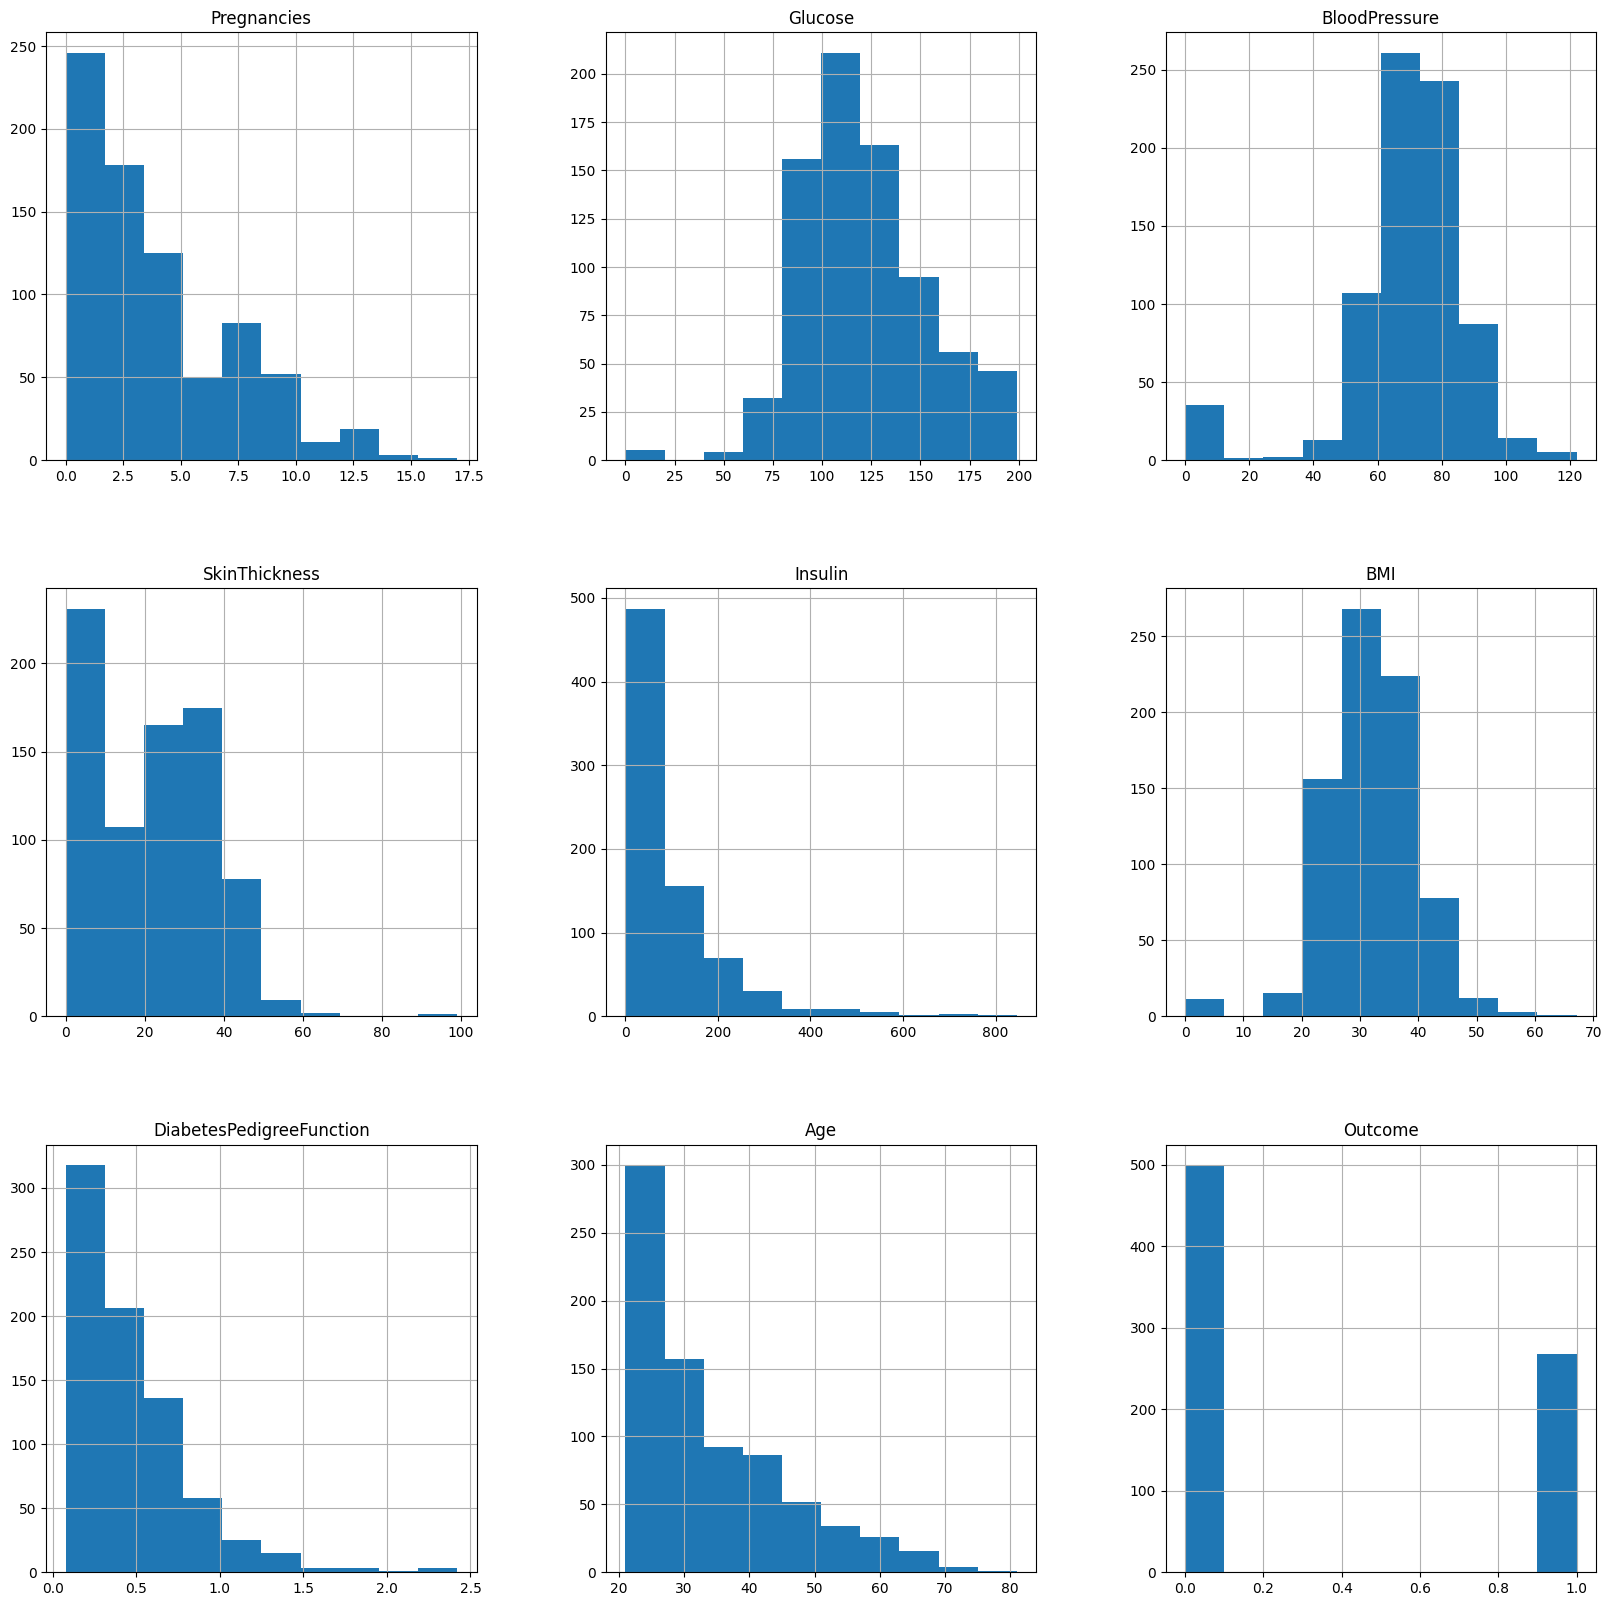

In [103]:

data_hist= df.hist(figsize = (20,20))


In [104]:
from sklearn.model_selection import train_test_split
X = df.drop('Outcome', axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])
print("Training set class distribution:")
print(y_train.value_counts())
print("Testing set class distribution:")
print(y_test.value_counts())

Training set size: 614
Testing set size: 154
Training set class distribution:
Outcome
0    400
1    214
Name: count, dtype: int64
Testing set class distribution:
Outcome
0    100
1     54
Name: count, dtype: int64


In [105]:
complete_data = X.copy(deep=True)
complete_data[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']] = complete_data[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']].replace(0, np.nan)


In [106]:
print("NULL Count:")
print(complete_data.isnull().sum())

NULL Count:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
dtype: int64


we have a large amount of null data

array([[<Axes: title={'center': 'Pregnancies'}>,
        <Axes: title={'center': 'Glucose'}>,
        <Axes: title={'center': 'BloodPressure'}>],
       [<Axes: title={'center': 'SkinThickness'}>,
        <Axes: title={'center': 'Insulin'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'DiabetesPedigreeFunction'}>,
        <Axes: title={'center': 'Age'}>, <Axes: >]], dtype=object)

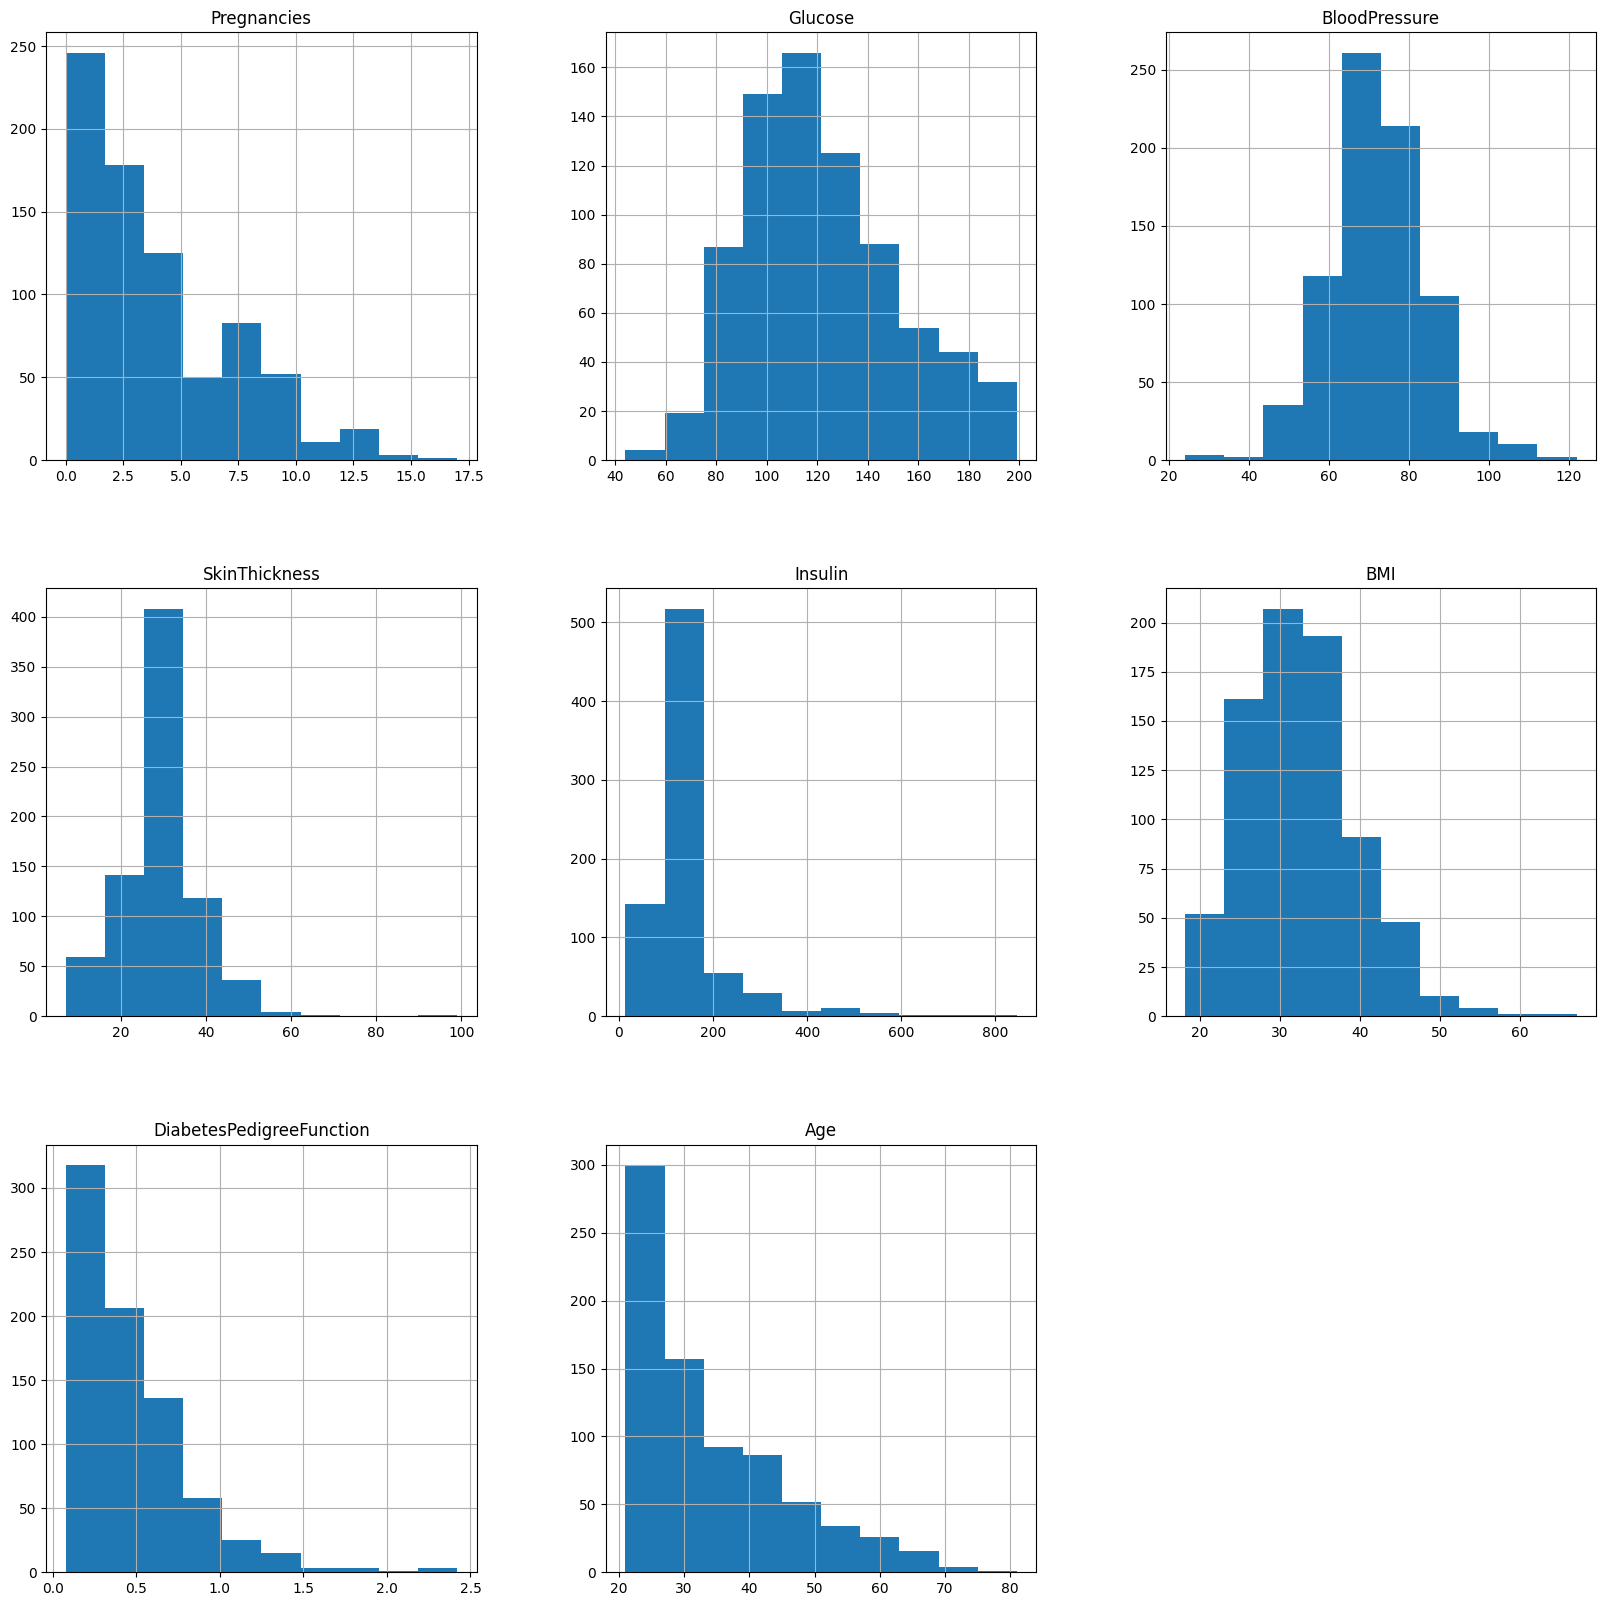

In [107]:
cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']


for col in cols_to_fix:
    complete_data[col] = complete_data[col].fillna(complete_data[col].median())

complete_data.hist(figsize=(20, 20))

/tmp/ipykernel_32106/1506657789.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=complete_data, x=col, ax=axes[i], palette="Set2")
/tmp/ipykernel_32106/1506657789.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=complete_data, x=col, ax=axes[i], palette="Set2")
/tmp/ipykernel_32106/1506657789.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=complete_data, x=col, ax=axes[i], palette="Set2")
/tmp/ipykernel_32106/1506657789.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be rem

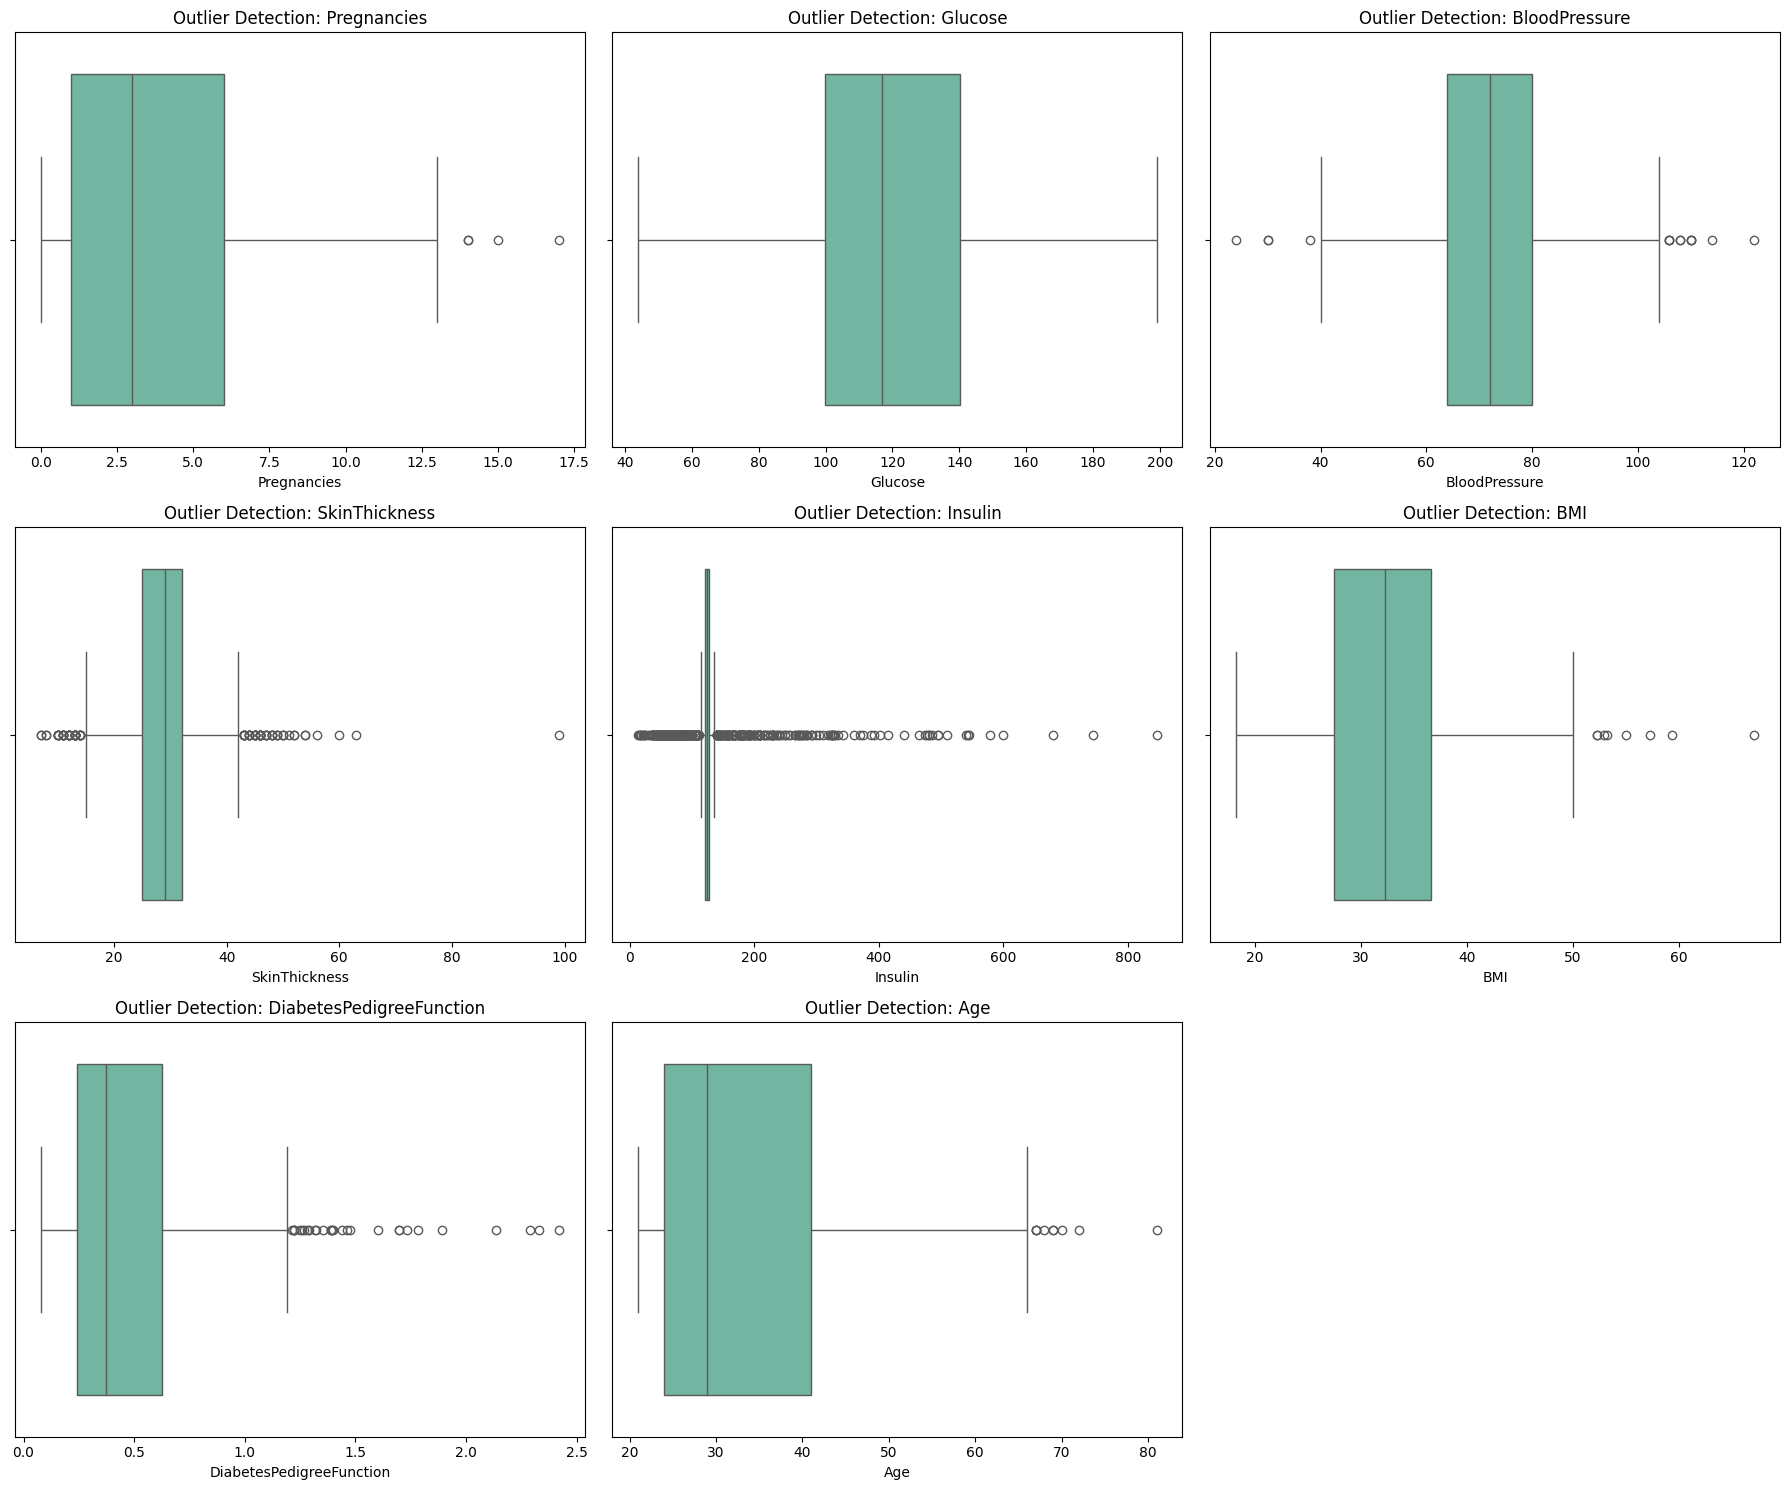

In [108]:
import seaborn as sns
import matplotlib.pyplot as plt


cols_to_plot = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
                'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten() 

for i, col in enumerate(cols_to_plot):
    sns.boxplot(data=complete_data, x=col, ax=axes[i], palette="Set2")
    axes[i].set_title(f'Outlier Detection: {col}')

fig.delaxes(axes[8])

plt.tight_layout()
plt.show()

In [112]:
# Update the list to include the "stubborn" columns
cols_to_fix = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
               'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

# Now re-run your cleaning loop
for col in cols_to_fix:
    complete_data[col] = complete_data[col].fillna(complete_data[col].median())
    # Add capping logic here if you want the dots to disappear
for col in cols_to_fix:
    Q1 = complete_data[col].quantile(0.25)
    Q3 = complete_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_whisker = Q1 - 1.5 * IQR
    upper_whisker = Q3 + 1.5 * IQR
    
    # Capping: Replace values outside whiskers with whisker values
    complete_data[col] = complete_data[col].clip(lower=lower_whisker, upper=upper_whisker)


/tmp/ipykernel_32106/1506657789.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=complete_data, x=col, ax=axes[i], palette="Set2")
/tmp/ipykernel_32106/1506657789.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=complete_data, x=col, ax=axes[i], palette="Set2")
/tmp/ipykernel_32106/1506657789.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=complete_data, x=col, ax=axes[i], palette="Set2")
/tmp/ipykernel_32106/1506657789.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be rem

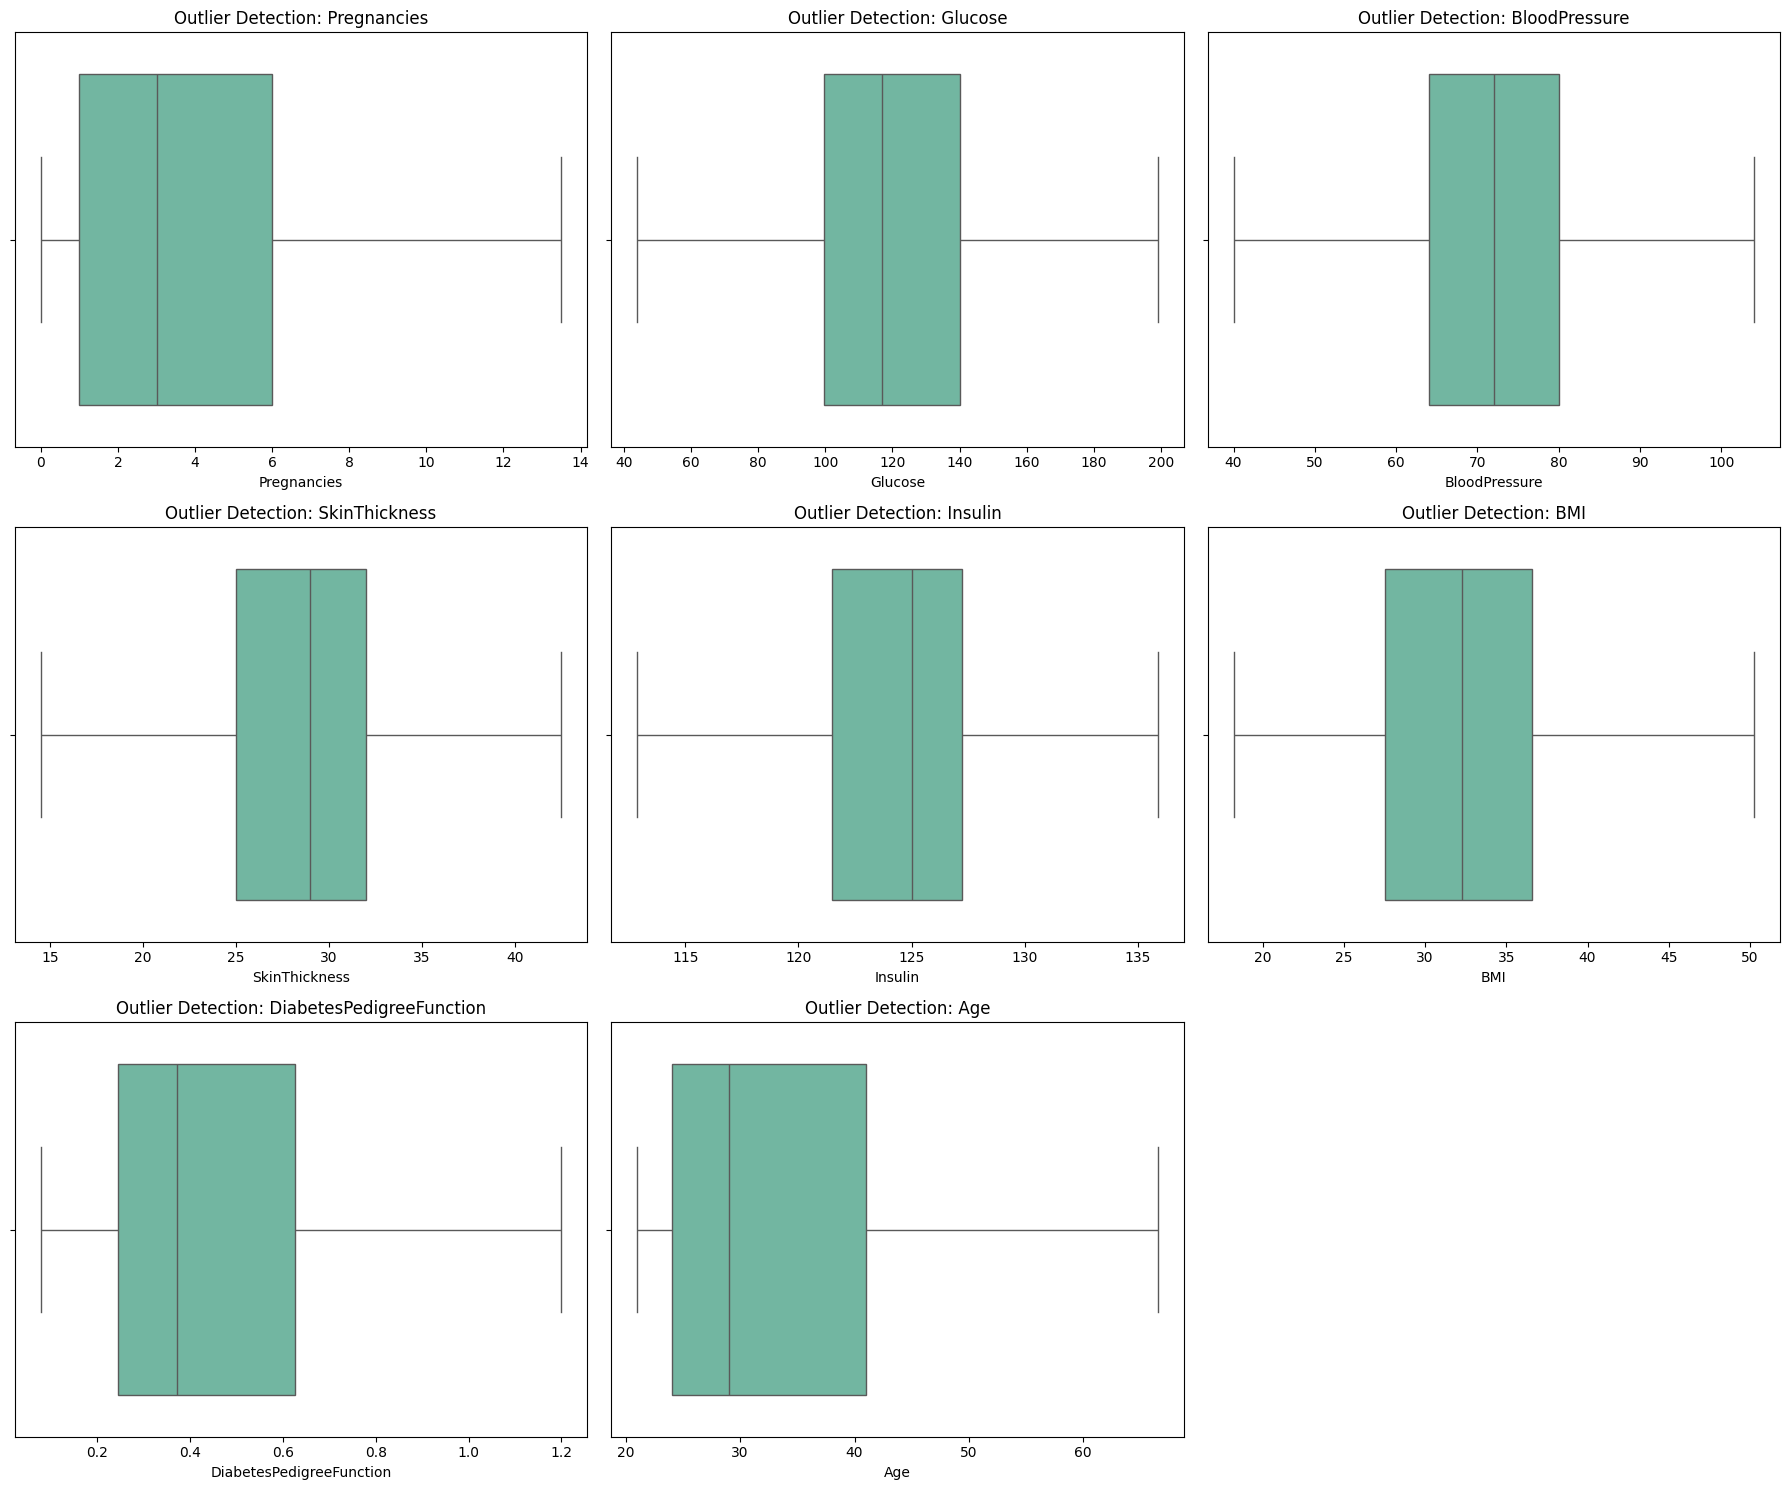

In [113]:


fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten() 

for i, col in enumerate(cols_to_plot):
    sns.boxplot(data=complete_data, x=col, ax=axes[i], palette="Set2")
    axes[i].set_title(f'Outlier Detection: {col}')

fig.delaxes(axes[8])

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(complete_data)

Text(0.5, 1.0, 'Correlation Heatmap')

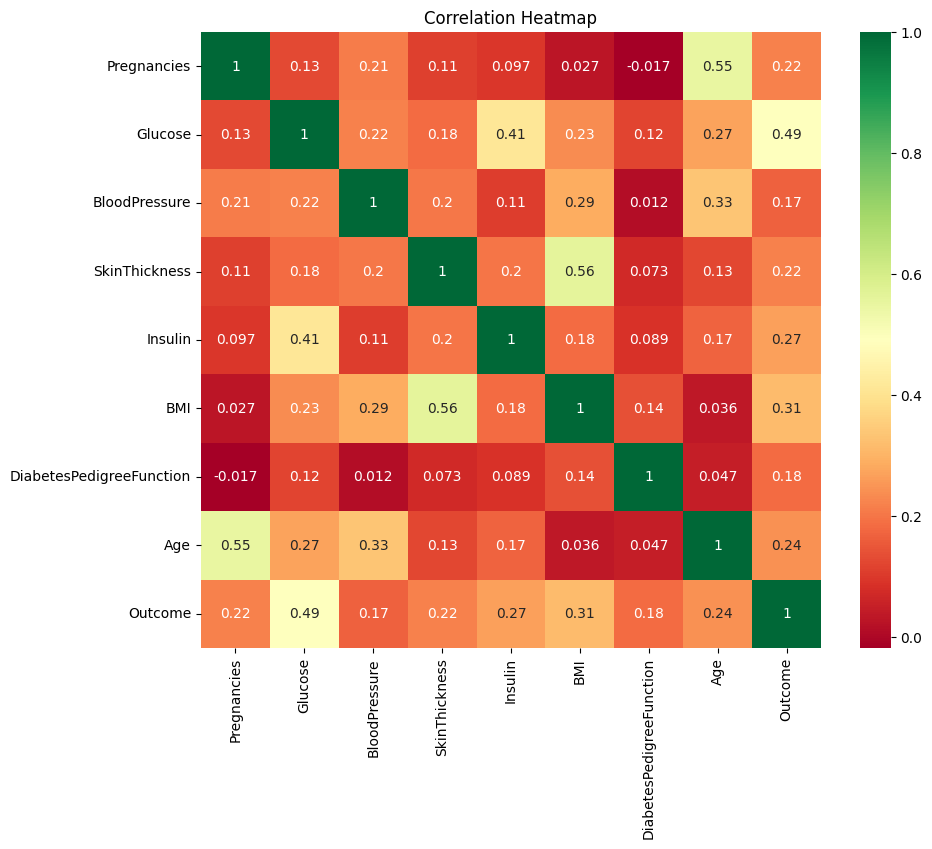

In [116]:
plt.figure(figsize=(10,8))
sns.heatmap(complete_data.join(y).corr(), annot=True, cmap='RdYlGn')
plt.title("Correlation Heatmap")